<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Classic_Machine_Learning/Forest_Cover_Type_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Task Definition
##Project Title

#Multiclass Forest Cover-Type Classification Using Standard and Class-Weighted Random Forest Models

1. Project Background

Forest cover classification is an important task in environmental monitoring, land management, ecosystem analysis, and forestry planning. Field surveys can provide reliable information about forest types, but collecting such data across large geographic areas can be expensive and time-consuming.

Environmental and topographic measurements can be used to estimate the dominant forest cover type of a geographic region. In this project, a machine-learning model will be developed to classify forest areas into one of seven forest cover categories.

The project will use the real-world Covertype dataset, which contains cartographic and environmental measurements collected from forested regions in the Roosevelt National Forest in Colorado, USA.

Data is available as fetch_covtype in scikit learn dataset package
(from sklearn.datasets import fetch_covtype)

The main goal is not only to build a classification model, but also to investigate how class imbalance affects Random Forest performance.

Two models will therefore be compared:

A standard Random Forest model without class weighting.
A balanced Random Forest model using class weights.


2. Problem Statement

The forest cover dataset contains seven target classes, but these classes are not equally represented. Some forest types contain a large number of observations, while others appear much less frequently.

A standard Random Forest treats every training observation equally. Consequently, the model may focus more strongly on the common classes because errors involving those classes contribute more heavily to the overall number of classification errors.

A class-weighted Random Forest assigns larger weights to observations from less frequent classes. This may improve minority-class detection, but it may also reduce precision or overall accuracy.

The central problem of this project is:

Can balanced class weighting improve the recognition of minority forest cover types without causing an unacceptable reduction in overall classification performance?


3. Dataset Description

The project will use the Covertype dataset.

Each row represents a forested geographic area.

The dataset contains approximately:

581,000 observations
54 input features
7 target classes

The input features include:

Continuous environmental features
elevation
aspect
slope
horizontal distance to hydrology
vertical distance to hydrology
horizontal distance to roadways
horizontal distance to wildfire ignition points
hillshade at 9:00 a.m.
hillshade at noon
hillshade at 3:00 p.m.
Binary indicator features
wilderness-area indicators
soil-type indicators

The target variable represents one of seven dominant forest cover types.


4. Main Research Questions

The project should answer the following questions:

*   How imbalanced are the seven forest cover classes?
*   Can a standard Random Forest classify the dominant classes  accurately?
*   Does the standard model perform poorly on any minority classes?
*   Does balanced class weighting improve minority-class recall?
*   Does class weighting reduce overall accuracy?
*   Does class weighting reduce minority-class precision?
*   Which model has the higher balanced accuracy?
*   Which model has the higher macro F1 score?
*   Which forest cover classes benefit most from class weighting?
*   Which classes are most frequently confused?
*   Is the balanced model genuinely better, or does it simply predict minority classes more frequently?
*   Which model is more appropriate for the stated environmental-management objective?





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
              classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
              balanced_accuracy_score, f1_score, precision_score, recall_score)

In [3]:
# Reading the data and splitting it as feature-target

dataset = fetch_covtype(as_frame = True)
X = dataset.data
y = dataset.target
print(X.shape, y.shape)


(581012, 54) (581012,)


### Alternative way to download and load the Forest Covertype dataset

Due to issues with `fetch_covtype`, you can manually download the dataset from the UCI Machine Learning Repository, unzip it, and load it using pandas.

In [4]:
'''# @title
# Download the gzipped dataset
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz

# Unzip the file (optional, pandas can often read gz directly)
!gunzip -f covtype.data.gz

# Define column names based on scikit-learn's fetch_covtype documentation
feature_names = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_1',
    'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4',
    'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5',
    'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10',
    'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14',
    'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18',
    'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22',
    'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26',
    'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30',
    'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34',
    'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37', 'Soil_Type_38',
    'Soil_Type_39', 'Soil_Type_40'
]

target_name = 'Cover_Type'

columns = feature_names + [target_name]

# Load the dataset using pandas
df_covtype = pd.read_csv('covtype.data', header=None, names=columns)

# Split features (X) and target (y)
X = df_covtype[feature_names]
y = df_covtype[target_name]'''

"# @title\n# Download the gzipped dataset\n!wget https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz\n\n# Unzip the file (optional, pandas can often read gz directly)\n!gunzip -f covtype.data.gz\n\n# Define column names based on scikit-learn's fetch_covtype documentation\nfeature_names = [\n    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',\n    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',\n    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',\n    'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_1',\n    'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4',\n    'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5',\n    'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10',\n    'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14',\n    'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18',\n    'Soil_Type_19', 'Soil_Type_20', 'Soil_T

In [5]:
# Display the first few rows and general characteristics of the data
print('Features (X) head:')
display(X.head())
print('\n\n\n\nTarget (y) head:')
display(y.head())
print('\n\n\n\nX info:')
X.info()

Features (X) head:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0






Target (y) head:


,Cover_Type
0,5
1,5
2,2
3,2
4,5






X info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Are

In [6]:
# Numerical Columns
numeric_col = ['Elevation', 'Aspect', 	'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
               'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 	'Hillshade_3pm',
               'Horizontal_Distance_To_Fire_Points']

# OneHot Columns
onehot_col = list(set(X.columns) - set(numeric_col))

In [7]:
# Evaluation of the label counts and proportions to check the lack of balance

valuecounts = pd.concat((y.value_counts(), y.value_counts(normalize=True)), axis = 1)
valuecounts

,count,proportion
Cover_Type,,
2,283301,0.487599
1,211840,0.364605
3,35754,0.061537
7,20510,0.035300
6,17367,0.029891
5,9493,0.016339
4,2747,0.004728


From the value_counts data frame, the proportion of different classes is obtained. The bar plot below also shows the distribution of this proportions.

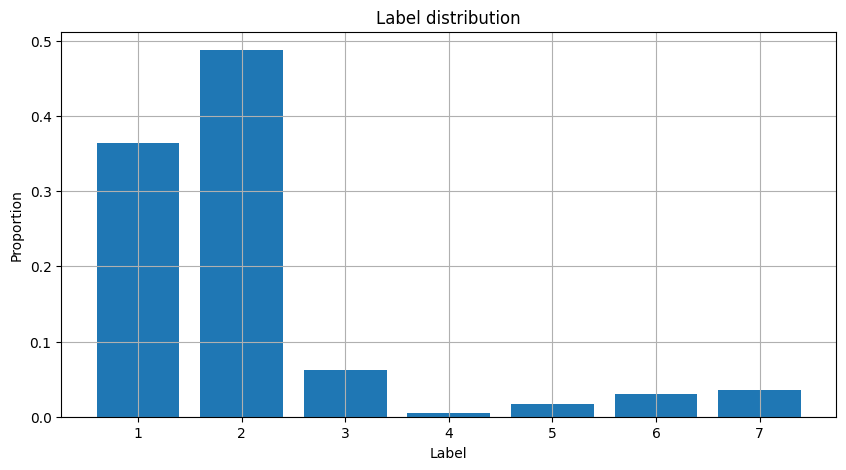

In [8]:
plt.figure(figsize = (10, 5))
plt.bar(x=valuecounts.index, height = valuecounts.proportion)
plt.xlabel("Label")
plt.ylabel("Proportion")
plt.title("Label distribution")
plt.grid()
plt.show()


In [9]:
# Splitting the date into train and test parts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)


Train size:  (464809, 54)
Test size:  (116203, 54)


###Analysis of the unbalanced (normal) data

In [10]:
# The raw data with its original class weights is analyzed

from sklearn.ensemble import RandomForestClassifier
norm_model = RandomForestClassifier(n_estimators = 200,
                                         class_weight = None,
                                         random_state = 42)

norm_model.fit(X_train, y_train)
norm_predict = norm_model.predict(X_test)

# Evaluation of the normal model metrics

norm_accuracy = accuracy_score(y_test, norm_predict)
balanced_norm_accuracy = balanced_accuracy_score(y_test, norm_predict)
norm_precision = precision_score(y_test, norm_predict, average = 'macro')
norm_f1 = f1_score(y_test, norm_predict, average = 'macro')


print(' accuracy score of the normal model: ', norm_accuracy)
print('balanced accuracy score of the normal model:', balanced_norm_accuracy)
print('precision score of the normal model: ', norm_precision)
print('f1 score of the normal model: ', norm_f1)



 accuracy score of the normal model:  0.9541836269287368
balanced accuracy score of the normal model: 0.9060042366479341
precision score of the normal model:  0.9466618710859163
f1 score of the normal model:  0.9247351957454975


**Analysis of balanced data**

In [11]:
# The balanced data with added weights is analyzed

bal_model = RandomForestClassifier(n_estimators = 200,
                                         class_weight = 'balanced',
                                         random_state = 42)

bal_model.fit(X_train, y_train)
bal_predict = bal_model.predict(X_test)

# Evaluation of the balanced model metrics

bal_accuracy = accuracy_score(y_test, bal_predict)
balanced_bal_accuracy = balanced_accuracy_score(y_test, bal_predict)
bal_precision = precision_score(y_test, bal_predict, average = 'macro')
bal_f1 = f1_score(y_test, bal_predict, average = 'macro')


print(' accuracy score of the balanced model: ', bal_accuracy)
print('balanced accuracy score of the balanced model:', balanced_bal_accuracy)
print('precision score of the balanced model: ', bal_precision)
print('f1 score of the balanced model: ', bal_f1)




 accuracy score of the balanced model:  0.9550786124282505
balanced accuracy score of the balanced model: 0.9085028797561466
precision score of the balanced model:  0.9460982737347926
f1 score of the balanced model:  0.9259664847786178


In [13]:
comparison = pd.DataFrame({
    'Model': ['Normal', 'Balanced'],
    'Accuracy': [norm_accuracy, bal_accuracy],
    'Balanced_Accuracy': [balanced_norm_accuracy, balanced_bal_accuracy],
    'Precision': [norm_precision, bal_precision],
    'F1 Score': [norm_f1, bal_f1]
})

comparison

,Model,Accuracy,Balanced_Accuracy,Precision,F1 Score
0,Normal,0.954184,0.906004,0.946662,0.924735
1,Balanced,0.955079,0.908503,0.946098,0.925966


In [15]:

# Evaluation of per class metrics, macro average and weighted average

print('Normal Model:\n',
    classification_report(
        y_test,
        norm_predict,
        digits = 4
    )
)



print('\n\nBalanced Model:\n',
    classification_report(
    y_test,
    bal_predict,
    digits = 4
))

Normal Model:
               precision    recall  f1-score   support

           1     0.9644    0.9423    0.9532     42368
           2     0.9492    0.9736    0.9612     56661
           3     0.9386    0.9599    0.9491      7151
           4     0.9155    0.8488    0.8809       549
           5     0.9535    0.7778    0.8567      1899
           6     0.9315    0.8926    0.9116      3473
           7     0.9739    0.9471    0.9603      4102

    accuracy                         0.9542    116203
   macro avg     0.9467    0.9060    0.9247    116203
weighted avg     0.9543    0.9542    0.9540    116203



Balanced Model:
               precision    recall  f1-score   support

           1     0.9663    0.9427    0.9544     42368
           2     0.9495    0.9745    0.9619     56661
           3     0.9386    0.9613    0.9498      7151
           4     0.9105    0.8525    0.8805       549
           5     0.9482    0.7899    0.8618      1899
           6     0.9359    0.8906    0.9127 

Both the normal and class-weighted random forest models achieve strong predictive performance, with accuracy above 95% and high precision, recall, and F1 scores for most classes. However, performance varies across classes, particularly for the less frequent classes 4 and 5.

The balanced model produces a small improvement in overall accuracy, increasing it from 0.9542 to 0.9551. Weighted F1 similarly increases from 0.9540 to 0.9549. Because these metrics are strongly influenced by the majority classes, these improvements mainly reflect slightly better overall sample-level classification.

The macro-average recall increases from 0.9060 to 0.9085. Since macro recall is equivalent to balanced accuracy in single-label multiclass classification, the balanced model shows a modest improvement in average class-wise detection. Macro F1 also increases slightly, from 0.9247 to 0.9260, indicating marginally better performance when all classes are given equal importance.

The largest meaningful improvement occurs for class 5, whose recall increases from 0.7778 to 0.7899 and whose F1 score increases from 0.8567 to 0.8618. This improvement is accompanied by a decrease in precision from 0.9535 to 0.9482, meaning that the balanced model detects more true class-5 samples but also produces slightly more false-positive predictions for this class.

Nevertheless, class weighting does not improve every minority class. For class 4, recall increases slightly, but precision and F1 decrease slightly. For class 6, precision and F1 improve marginally, while recall decreases. Therefore, the effect of class weighting is class-dependent rather than uniformly beneficial.

Overall, the balanced model performs marginally better according to accuracy, weighted F1, macro recall, and macro F1. However, the differences are small, so it cannot be concluded from a single train–test split that the balanced model is substantially superior. Repeated stratified cross-validation or confidence intervals would be needed to determine whether these improvements are stable.

If identifying minority-class observations—especially class 5—is important, the balanced model would be preferable. If false positives carry a high cost, the normal model may still be suitable. The final choice should therefore depend on the relative cost of false negatives and false positives for each class.

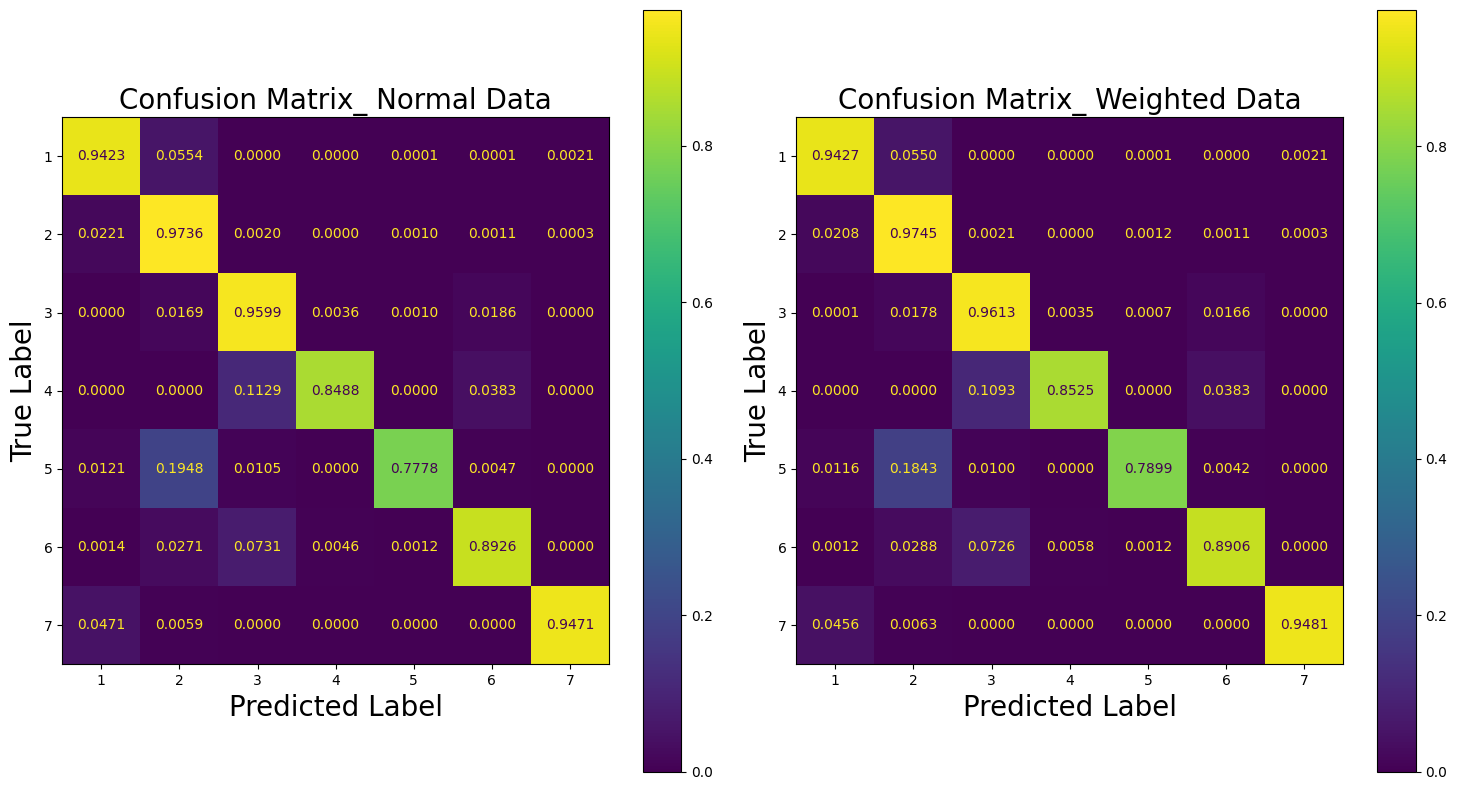

In [22]:
cm_norm = confusion_matrix(y_test, norm_predict, normalize = "true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix = cm_norm, display_labels = norm_model.classes_)

cm_bal = confusion_matrix(y_test, bal_predict, normalize = 'true')
disp_bal = ConfusionMatrixDisplay(confusion_matrix = cm_bal, display_labels = bal_model.classes_)


fig, axs = plt.subplots(1, 2, figsize = (15, 8))
disp_norm.plot(ax = axs[0], values_format = "0.4f")
axs[0].set_title('Confusion Matrix_ Normal Data', fontsize = 20)

disp_bal.plot(ax = axs[1], values_format = "0.4f")
axs[1].set_title('Confusion Matrix_ Weighted Data', fontsize = 20)

axs[0].set_ylabel('True Label', fontsize = 20)
axs[1].set_ylabel('True Label', fontsize = 20)

axs[0].set_xlabel('Predicted Label', fontsize = 20)
axs[1].set_xlabel('Predicted Label', fontsize = 20)

plt.tight_layout()
plt.show()